Importing Essential libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

The dataset is loaded from the Excel file, and its first few records, size and missing values are checked

to understand the data before training the model.

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_excel(next(iter(uploaded)))

# Displaying the first few rows
print(df.head())

# Checking the size of the dataset
print("\nDataset Shape:", df.shape)

# Checking for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Saving numiqo.xlsx to numiqo.xlsx
        Disease  Age  Gender Smoker status
0      diseased   43    Male        Smoker
1  not diseased   18    Male        Smoker
2      diseased   22  Female    Non-smoker
3      diseased   25    Male    Non-smoker
4  not diseased   45  Female        Smoker

Dataset Shape: (36, 4)

Missing Values:
Disease          0
Age              0
Gender           0
Smoker status    0
dtype: int64


Converting categorical values into numerical values

In [4]:
df["Disease"] = df["Disease"].map({"diseased":1,"not diseased":0})
df["Gender"] = df["Gender"].map({"Male":1,"Female":0})
df["Smoker status"] = df["Smoker status"].map({"Smoker":1,"Non-smoker":0})

Selecting the input features and target variable

In [5]:
X=df[["Age","Gender","Smoker status"]]
y=df["Disease"]

Splitting the dataset into training and testing sets

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Creating the Logistic Regression model
model=LogisticRegression(max_iter=1000)

# Training the model
model.fit(X_train,y_train)

# Predicting the test data
y_pred=model.predict(X_test)

# Displaying the predicted values
print("\nPredicted Values:")
print(y_pred)


Predicted Values:
[0 1 0 1 0 1 1 0]


In [8]:
# Calculating the accuracy
acc=metrics.accuracy_score(y_test,y_pred)

print("\nAccuracy Score:",acc)
print("Accuracy Percentage:",round(acc*100,2),"%")

# Displaying the confusion matrix
conf_mat=metrics.confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix:")
print(conf_mat)



Accuracy Score: 0.75
Accuracy Percentage: 75.0 %

Confusion Matrix:
[[2 0]
 [2 4]]


Plotting confusion matrix

<Axes: xlabel='Predicted', ylabel='Actual'>

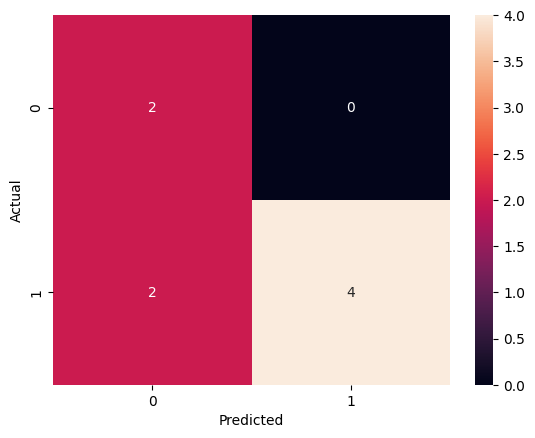

In [9]:
# Plotting the confusion matrix
conf_df=pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

sn.heatmap(conf_df,annot=True)

Predicting for a new person given their ge gender and Smoker status

In [10]:
new_person=pd.DataFrame({
    "Age":[35],
    "Gender":[1],
    "Smoker status":[1]
})

prediction=model.predict(new_person)

print("\nPrediction for New Person:")

if prediction[0]==1:
    print("The person is likely to have the disease.")
else:
    print("The person is unlikely to have the disease.")


Prediction for New Person:
The person is likely to have the disease.
